In [ ]:
# Intelligent EV Charging Demand Predictions:
# Problem Statement:
    # The objective of this project is to predict Energy Consumed (kWh) during an EV charging session using historical charging station usage, time, and location data.
# Machine Learning Framing:
    # This is a Supervised Regression Problem, where:
        # Input (X): Charging session features
        # Output (y): Energy Consumed (kWh)
    # Evaluation metrics:
        # MAE (Mean Absolute Error)
        # RMSE (Root Mean Squared Error)
        # R² Score

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [8]:
df = pd.read_csv("../data/Raw_Dataset.csv")
df.head()

,Vehicle Model,Battery Capacity (kWh),Charging Station Location,Charging Start Time,Charging Duration (hours),Charging Rate (kW),Energy Consumed (kWh),State of Charge (Start %),State of Charge (End %),Temperature (°C),Vehicle Age (years),Charger Type,User Type
0,Hyundai Kona,64.001551,Chicago,2024-01-20 00:00:00,4.997142,6.841223,33.961284,54.044407,100.000000,13.665165,4,Level 1,Casual Driver
1,Chevy Bolt,69.908699,Houston,2024-01-05 06:00:00,3.516591,8.018278,17.092252,16.302991,40.229932,NaN,9,Level 1,Long-Distance Traveler
2,BMW i3,43.348721,Los Angeles,2024-02-16 22:00:00,4.954913,8.003122,33.327562,41.734900,100.000000,39.266606,2,Level 1,Long-Distance Traveler
3,Chevy Bolt,53.895991,Houston,2024-02-11 19:00:00,3.469848,16.010062,38.499346,64.292994,100.000000,37.001947,4,Level 2,Commuter
4,Chevy Bolt,65.786490,San Francisco,2024-02-08 02:00:00,3.800571,5.478248,9.360598,67.943386,85.329155,39.061878,1,Level 1,Commuter


In [9]:
df.shape

(1800, 13)

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1800 entries, 0 to 1799
Data columns (total 13 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Vehicle Model              1800 non-null   object 
 1   Battery Capacity (kWh)     1696 non-null   float64
 2   Charging Station Location  1800 non-null   object 
 3   Charging Start Time        1800 non-null   object 
 4   Charging Duration (hours)  1800 non-null   float64
 5   Charging Rate (kW)         1712 non-null   float64
 6   Energy Consumed (kWh)      1800 non-null   float64
 7   State of Charge (Start %)  1800 non-null   float64
 8   State of Charge (End %)    1800 non-null   float64
 9   Temperature (°C)           1731 non-null   float64
 10  Vehicle Age (years)        1800 non-null   int64  
 11  Charger Type               1800 non-null   object 
 12  User Type                  1800 non-null   object 
dtypes: float64(7), int64(1), object(5)
memory usage:

In [11]:
df.isnull().sum()

Vehicle Model                  0
Battery Capacity (kWh)       104
Charging Station Location      0
Charging Start Time            0
Charging Duration (hours)      0
Charging Rate (kW)            88
Energy Consumed (kWh)          0
State of Charge (Start %)      0
State of Charge (End %)        0
Temperature (°C)              69
Vehicle Age (years)            0
Charger Type                   0
User Type                      0
dtype: int64

In [12]:
# Data Cleaning

In [13]:
df["Energy Consumed (kWh)"].isnull().sum()

np.int64(0)

In [14]:
(df.isnull().sum() / len(df)) * 100

Vehicle Model                0.000000
Battery Capacity (kWh)       5.777778
Charging Station Location    0.000000
Charging Start Time          0.000000
Charging Duration (hours)    0.000000
Charging Rate (kW)           4.888889
Energy Consumed (kWh)        0.000000
State of Charge (Start %)    0.000000
State of Charge (End %)      0.000000
Temperature (°C)             3.833333
Vehicle Age (years)          0.000000
Charger Type                 0.000000
User Type                    0.000000
dtype: float64

In [15]:
df["Battery Capacity (kWh)"] = df["Battery Capacity (kWh)"].fillna(
    df["Battery Capacity (kWh)"].median()
)
df["Charging Rate (kW)"] = df["Charging Rate (kW)"].fillna(
    df["Charging Rate (kW)"].median()
)
df["Temperature (°C)"] = df["Temperature (°C)"].fillna(
    df["Temperature (°C)"].median()
)

In [16]:
df.isnull().sum()

Vehicle Model                0
Battery Capacity (kWh)       0
Charging Station Location    0
Charging Start Time          0
Charging Duration (hours)    0
Charging Rate (kW)           0
Energy Consumed (kWh)        0
State of Charge (Start %)    0
State of Charge (End %)      0
Temperature (°C)             0
Vehicle Age (years)          0
Charger Type                 0
User Type                    0
dtype: int64

In [17]:
# EDA and Graphs

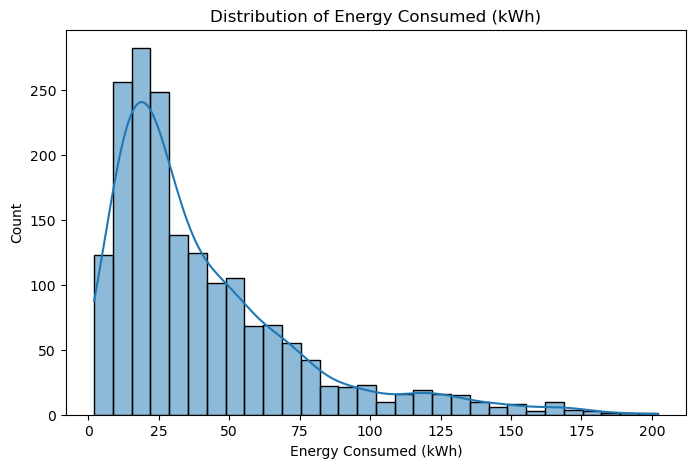

In [18]:
plt.figure(figsize=(8,5))
sns.histplot(df["Energy Consumed (kWh)"], bins=30, kde=True)
plt.title("Distribution of Energy Consumed (kWh)")
plt.show()

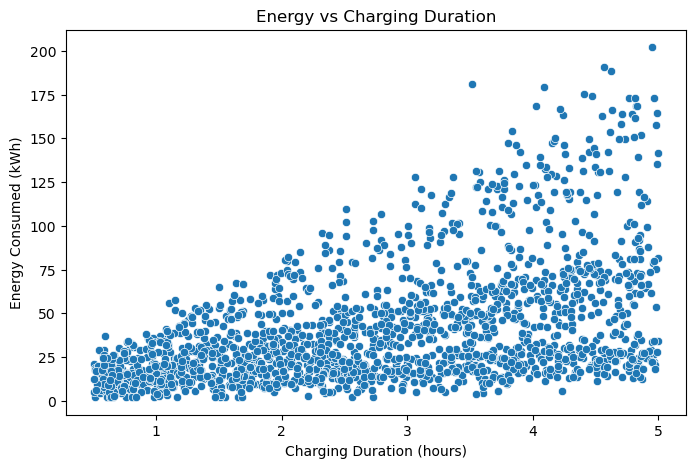

In [19]:
plt.figure(figsize=(8,5))
sns.scatterplot(
    x="Charging Duration (hours)",
    y="Energy Consumed (kWh)",
    data=df
)
plt.title("Energy vs Charging Duration")
plt.show()

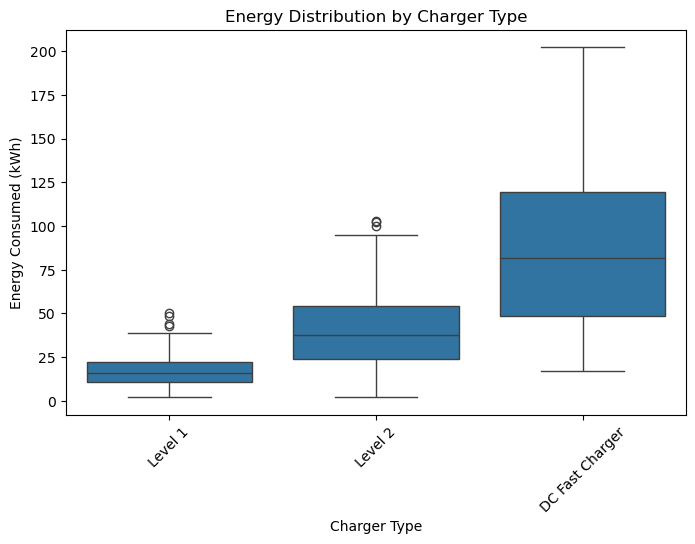

In [20]:
plt.figure(figsize=(8,5))
sns.boxplot(
    x="Charger Type",
    y="Energy Consumed (kWh)",
    data=df
)
plt.xticks(rotation=45)
plt.title("Energy Distribution by Charger Type")
plt.show()

In [21]:
df[["Charging Duration (hours)", 
    "Charging Rate (kW)", 
    "Energy Consumed (kWh)"]].corr()

,Charging Duration (hours),Charging Rate (kW),Energy Consumed (kWh)
Charging Duration (hours),1.000000,-0.032059,0.497478
Charging Rate (kW),-0.032059,1.000000,0.717112
Energy Consumed (kWh),0.497478,0.717112,1.000000


In [22]:
df["soc_change"] = (
    df["State of Charge (End %)"] -
    df["State of Charge (Start %)"]
)
df = df.drop(columns=[
    "State of Charge (Start %)",
    "State of Charge (End %)"
])

In [23]:
df.shape

(1800, 12)

In [25]:
df["Charging Start Time"] = pd.to_datetime(df["Charging Start Time"])

In [26]:
df["hour"] = df["Charging Start Time"].dt.hour
df["month"] = df["Charging Start Time"].dt.month
df["day_of_week"] = df["Charging Start Time"].dt.dayofweek
df["is_weekend"] = df["day_of_week"].apply(lambda x: 1 if x >= 5 else 0)

In [27]:
df = df.drop(columns=["Charging Start Time"])

In [28]:
df.shape

(1800, 15)

In [29]:
# Model Training 

In [30]:
target = "Energy Consumed (kWh)"
X = df.drop(columns=[target])
y = df[target]

In [31]:
categorical_cols = X.select_dtypes(include="object").columns
categorical_cols

Index(['Vehicle Model', 'Charging Station Location', 'Charger Type',
       'User Type'],
      dtype='object')

In [32]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [33]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols)
    ],
    remainder="passthrough"
)

rf_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor(
        n_estimators=200,
        random_state=42
    ))
])

In [34]:
rf_model.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('cat', ...)]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [35]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

y_pred = rf_model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("Random Forest Results:")
print("MAE:", mae)
print("RMSE:", rmse)
print("R2:", r2)

Random Forest Results:
MAE: 3.758582336216392
RMSE: 6.078707650407887
R2: 0.9624427318075257


In [36]:
import joblib

joblib.dump(rf_model, "../models/ev_demand_model.pkl")

['../models/ev_demand_model.pkl']